# L05 Assignment — Segmentation + Anomaly Detection

> *Two short, focused exercises. Apply the L05 toolkit to two new domains.*

1. **Part A — E-commerce customer segmentation.** A new retailer with 8,000 customers wants 4–6 segments for marketing.
2. **Part B — Credit-card anomaly detection.** A bank wants the most unusual transactions flagged for fraud review.

**Sample solutions** at the bottom of the notebook. Attempt each part before scrolling.

**Time budget:** ~75 minutes.

---

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (11, 4.5)
print("✅ Setup complete.")

✅ Setup complete.


---

## 📚 Choose your track

This assignment has **two tracks**. Pick **one** based on your background — you don't need to do both.

| Track | Who it's for | What you'll do |
|---|---|---|
| **🟢 Foundational Track** | Learners new to ML / programming | Part A — StyleHub customer segmentation (PCA + K-Means + profiling) |
| **🔵 Advanced Track** | Learners with prior ML background | Part B — credit-card anomaly detection with Isolation Forest |

If you're unsure, start with the **Foundational Track**. If it feels easy, skip ahead to the **Advanced Track** — both tracks cover the same lesson outcomes; only the scaffolding differs.

---


---

# 🟢 Foundational Track

> *No prior ML background needed. The cells below are scaffolded — read the worked example, then fill in the blanks. Hints are included.*

---


# Part A — E-commerce Customer Segmentation

A new B2C retailer (call them **StyleHub**) hands you a customer file. They want a few clean segments for marketing — *not* a deep statistical analysis. Friday's deliverable: 4–6 named segments + a paragraph describing each.

## Generate the StyleHub data

In [2]:
def generate_stylehub_data(n=8000, seed=2027):
    rng = np.random.default_rng(seed)

    # Three latent customer types — but the model shouldn't know that
    type_idx = rng.choice([0, 1, 2, 3], size=n, p=[0.40, 0.25, 0.20, 0.15])

    age = np.where(type_idx == 0, rng.normal(28, 6, n),
          np.where(type_idx == 1, rng.normal(45, 10, n),
          np.where(type_idx == 2, rng.normal(58, 8, n),
                                   rng.normal(34, 12, n)))).clip(18, 80).round()

    annual_spend = np.where(type_idx == 0, rng.normal(150, 60, n),
                    np.where(type_idx == 1, rng.normal(800, 200, n),
                    np.where(type_idx == 2, rng.normal(1500, 350, n),
                                              rng.normal(300, 150, n)))).clip(20, 5000).round(2)

    sessions_per_month = rng.poisson(
        lam=np.where(type_idx == 0, 12,
              np.where(type_idx == 1, 6,
              np.where(type_idx == 2, 3, 10))), size=n).clip(0, 50)

    avg_basket_size = np.where(type_idx == 0, rng.normal(35, 10, n),
                       np.where(type_idx == 1, rng.normal(120, 30, n),
                       np.where(type_idx == 2, rng.normal(200, 50, n),
                                                 rng.normal(50, 15, n)))).clip(10, 800).round(2)

    discount_use_rate = np.where(type_idx == 0, rng.beta(8, 3, n),
                          np.where(type_idx == 1, rng.beta(3, 8, n),
                          np.where(type_idx == 2, rng.beta(2, 12, n),
                                                    rng.beta(6, 4, n)))).round(2)

    months_since_signup = np.where(type_idx == 0, rng.uniform(0, 18, n),
                            np.where(type_idx == 1, rng.uniform(12, 60, n),
                            np.where(type_idx == 2, rng.uniform(24, 96, n),
                                                      rng.uniform(0, 24, n)))).round()

    days_since_last_purchase = rng.exponential(scale=30, size=n).clip(0, 365).round()

    preferred_channel = rng.choice(["app", "web", "email"], size=n, p=[0.45, 0.40, 0.15])

    return pd.DataFrame({
        "customer_id":              np.arange(700000, 700000 + n),
        "age":                      age,
        "annual_spend_gbp":         annual_spend,
        "sessions_per_month":       sessions_per_month,
        "avg_basket_size_gbp":      avg_basket_size,
        "discount_use_rate":        discount_use_rate,
        "months_since_signup":      months_since_signup,
        "days_since_last_purchase": days_since_last_purchase,
        "preferred_channel":        preferred_channel,
    })

stylehub = generate_stylehub_data()
print(f"StyleHub dataset: {len(stylehub):,} customers × {stylehub.shape[1]} columns")
stylehub.head()

StyleHub dataset: 8,000 customers × 9 columns


,customer_id,age,annual_spend_gbp,sessions_per_month,avg_basket_size_gbp,discount_use_rate,months_since_signup,days_since_last_purchase,preferred_channel
0,700000,33.0,95.55,7,52.90,0.73,18.0,20.0,app
1,700001,27.0,73.42,13,33.98,0.50,14.0,42.0,app
2,700002,32.0,84.51,12,44.87,0.78,8.0,9.0,app
3,700003,47.0,820.09,3,124.08,0.37,23.0,34.0,app
4,700004,55.0,762.40,12,65.77,0.19,54.0,22.0,web


## Exercise A1 — Build the preprocessor + run PCA

**Tasks:**
1. Define `X_styled` = features (drop `customer_id`).
2. Build a ColumnTransformer (median imputer + StandardScaler for numerics; OneHotEncoder for `preferred_channel`).
3. Fit PCA with `n_components=2` and plot the customers in 2D space.

*Your code:*

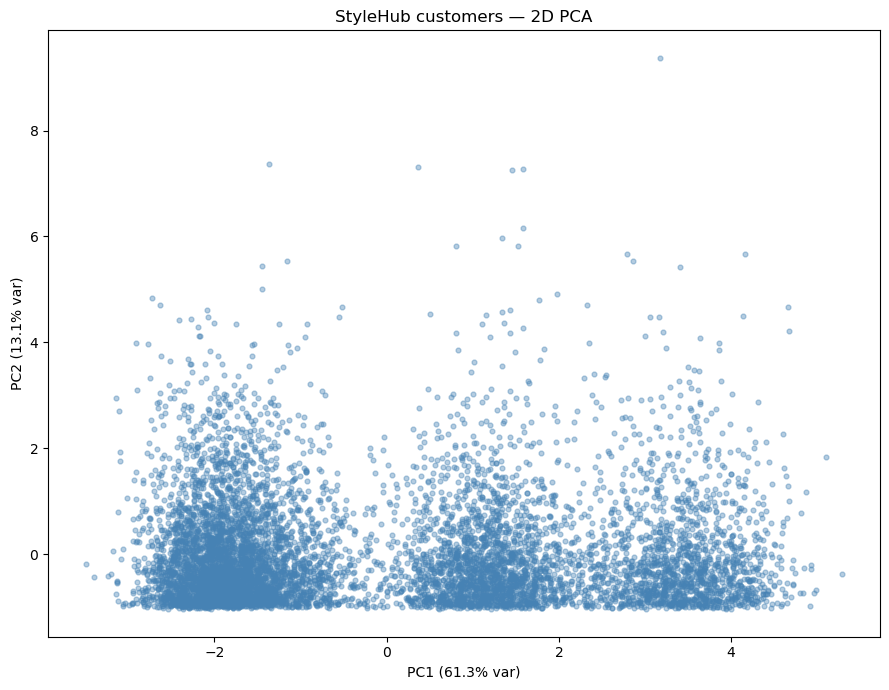

Variance captured in 2D: 74.4%


In [3]:
# Exercise A1 — preprocessor + PCA

# Step 1: Define features (drop the ID column — it's not a feature)
X_styled = stylehub.drop(columns=["customer_id"])

# Step 2: List the column names by type
numeric_cols    = ["age", "annual_spend_gbp", "sessions_per_month",
                   "avg_basket_size_gbp", "discount_use_rate",
                   "months_since_signup", "days_since_last_purchase"]
categorical_cols = ["preferred_channel"]


# Step 3: Build a ColumnTransformer
#   - For numeric columns:  median imputer → StandardScaler
#   - For categorical cols: most_frequent imputer → OneHotEncoder (handle_unknown="ignore", sparse_output=False)
prep_a = ColumnTransformer([
    ("num", Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("scl", StandardScaler()),
    ]), numeric_cols),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("enc", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), categorical_cols),
])

# Step 4: Fit-transform the data
X_proc = prep_a.fit_transform(X_styled)

# Step 5: Fit PCA with 2 components and transform
pca_a = PCA(n_components=2)
X_2d  = pca_a.fit_transform(X_proc)


# Step 6: Scatter plot — colour by nothing for now (we'll add clusters in A3)
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.4, s=12, color="steelblue")
ax.set_xlabel(f"PC1 ({pca_a.explained_variance_ratio_[0]:.1%} var)")
ax.set_ylabel(f"PC2 ({pca_a.explained_variance_ratio_[1]:.1%} var)")
ax.set_title("StyleHub customers — 2D PCA")
plt.tight_layout(); plt.show()

print(f"Variance captured in 2D: {pca_a.explained_variance_ratio_.sum():.1%}")



## Exercise A2 — Choose K with elbow + silhouette + business judgement

**Tasks:**
1. Compute K-Means for K = 2, 3, 4, 5, 6, 7. Track inertia AND silhouette.
2. Plot both as functions of K.
3. Pick a K. State your reasoning in a comment (don't just pick the highest silhouette — also consider how many segments marketing can act on).

*Your code:*

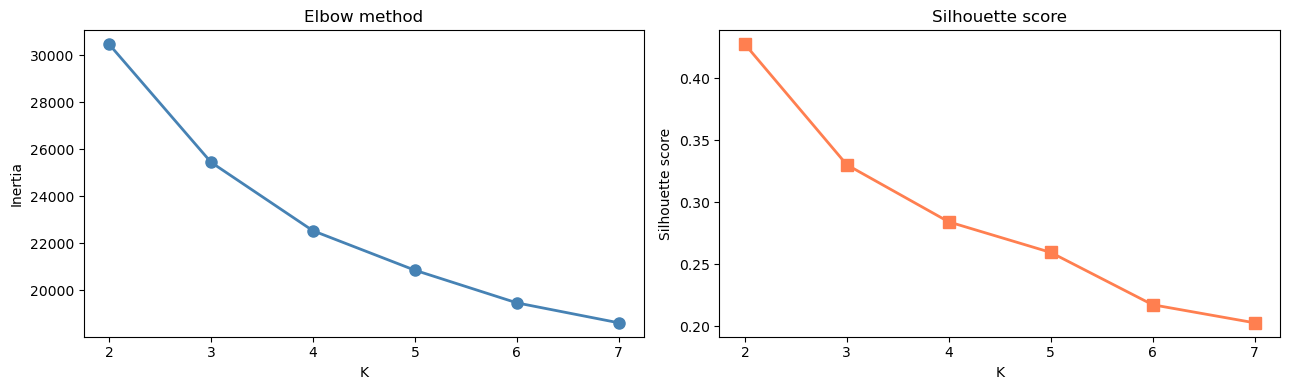

Chosen K = 4. Silhouette = 0.2842


In [7]:
# Exercise A2 — choose K

K_range = range(2, 8)
inertias, silhouettes = [], []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_proc)          # use X_proc from A1
    inertias.append(km.inertia_)                  # hint: km.inertia_
    silhouettes.append(silhouette_score(X_proc, labels))

# Plot elbow + silhouette side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(K_range, inertias, "o-", color="steelblue", linewidth=2, markersize=8)
axes[0].set_xlabel("K"); 
axes[0].set_ylabel("Inertia");
axes[0].set_title("Elbow method")

axes[1].plot(K_range, silhouettes, "s-", color="coral", linewidth=2, markersize=8)
axes[1].set_xlabel("K");
axes[1].set_ylabel("Silhouette score"); 
axes[1].set_title("Silhouette score")

plt.tight_layout(); 
plt.show()

# Choose K — write your reasoning as a comment
# Hint: silhouette tells you statistical separation; business context tells you how many
#       segments marketing can realistically act on. 4–6 is usually actionable.

chosen_k = 4  # fill in your choice
print(f"Chosen K = {chosen_k}. Silhouette = {silhouettes[chosen_k - 2]:.4f}")

## Exercise A3 — Profile and name your segments

**Tasks:**
1. Fit K-Means with your chosen K.
2. For each cluster, compute the mean of every numerical feature.
3. Display as a heatmap of Z-scores against the global mean.
4. Give each cluster a 2–3 word business name (in a comment or markdown cell).

*Your code:*

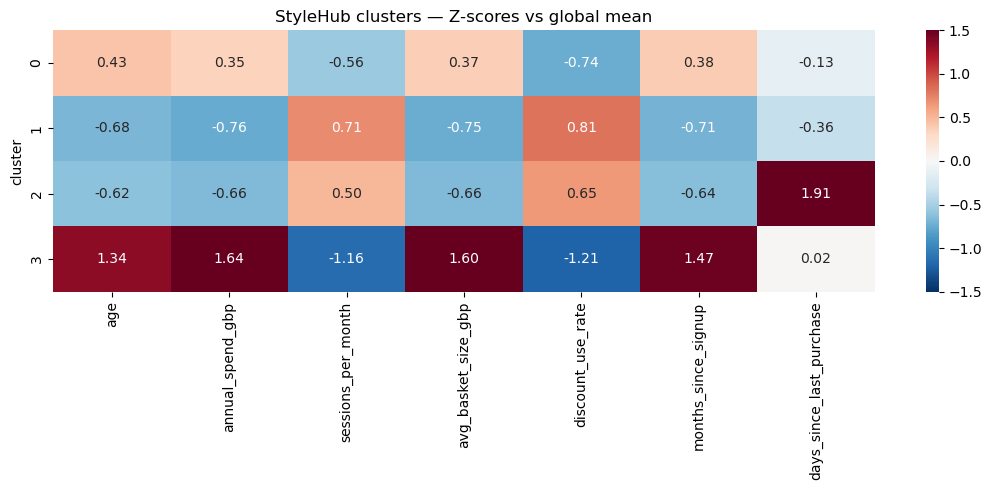

Cluster sizes:
cluster
0    2097
1    3583
2     789
3    1531
Name: count, dtype: int64


In [ ]:
# Exercise A3 — profile and name clusters
import seaborn as sns

# Step 1: Fit final K-Means using your chosen_k from A2
km_final = KMeans(n_clusters=chosen_k, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_proc)      # use X_proc from A1

# Step 2: Attach cluster labels back to the original dataframe
stylehub["cluster"] = cluster_labels

# Step 3: Compute mean of numeric features per cluster
profile = stylehub.groupby("cluster")[numeric_cols].mean()

# Step 4: Standardise to Z-scores (so all features are on the same scale)
global_mean = stylehub[numeric_cols].mean()
global_std  = stylehub[numeric_cols].std()
z_scores    = (profile - global_mean) / global_std

# Step 5: Heatmap
fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(z_scores.round(2), annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, vmin=-1.5, vmax=1.5, ax=ax)
ax.set_title("StyleHub clusters — Z-scores vs global mean")
plt.tight_layout(); plt.show()

print("Cluster sizes:")
print(stylehub["cluster"].value_counts().sort_index())

# Step 6: Give each cluster a 2–3 word business name based on the heatmap
# Look at which features are strongly positive (red) or negative (blue) per cluster.
# Example:
#   Cluster 0 → "Browsing Peeps - older customers because do not visit the site often or use any discounts, probably older customers"   (because ...)
#   Cluster 1 → "Bargain Hunters  - because react to discounts and check online frequently for promotions"
#   Cluster 2 → "New Discount Lured Customers - because recent purchase but no purchase history or large basket size. Do prefer to buy with the discount"
#   Cluster 3 → "Regular customers - because spend above average, larger basket size and signed up long time ago."

---

# 🔵 Advanced Track

> *For learners with prior ML background. Minimal scaffolding — you decide the approach. You're welcome to peek at the Foundational Track above for reference.*

---


# Part B — Credit-Card Anomaly Detection

The same bank from L04 (Lakeside Bank) wants to flag transactions for fraud review. There are NO fraud labels yet. You have ~5,000 historical transactions; find the 50 most unusual.

## Generate the transaction data

In [9]:
def generate_transactions(n=5000, seed=2028):
    rng = np.random.default_rng(seed)
    return pd.DataFrame({
        "transaction_id":         np.arange(800000, 800000 + n),
        "amount_gbp":             np.round(rng.lognormal(mean=3.8, sigma=1.0, size=n).clip(1, 8000), 2),
        "hour_of_day":            rng.integers(0, 24, size=n),
        "is_weekend":             rng.binomial(1, 0.28, size=n),
        "days_since_last_txn":    rng.exponential(scale=2.0, size=n).clip(0, 60).round(1),
        "txns_last_24h":          rng.poisson(lam=2.5, size=n).clip(0, 30),
        "distance_from_home_km":  rng.exponential(scale=20, size=n).clip(0, 5000).round(1),
        "merchant_category":      rng.choice(["grocery", "fuel", "restaurant", "online", "atm", "travel", "other"],
                                              size=n, p=[0.25, 0.10, 0.15, 0.25, 0.10, 0.05, 0.10]),
        "card_present":           rng.choice(["yes", "no"], size=n, p=[0.55, 0.45]),
    })

txns = generate_transactions()
print(f"Transaction dataset: {len(txns):,} transactions × {txns.shape[1]} columns")
txns.head()

Transaction dataset: 5,000 transactions × 9 columns


,transaction_id,amount_gbp,hour_of_day,is_weekend,days_since_last_txn,txns_last_24h,distance_from_home_km,merchant_category,card_present
0,800000,35.17,22,1,1.7,2,14.9,other,no
1,800001,144.35,1,0,0.6,3,30.5,atm,no
2,800002,10.12,7,1,5.7,2,48.9,online,no
3,800003,7.53,23,0,0.2,2,40.2,grocery,no
4,800004,17.38,8,0,1.7,3,37.9,grocery,no


## Exercise B1 — Fit Isolation Forest + score every transaction

**Tasks:**
1. Define `X_txn` = features (drop `transaction_id`).
2. Build a preprocessor (impute + scale + one-hot).
3. Fit `IsolationForest(contamination='auto', n_estimators=100)`.
4. Add `anomaly_score` and `is_anomaly` columns to `txns`.

> **Heads-up about `contamination='auto'`:** on this synthetic dataset `auto` is permissive — it'll likely flag ~30% of transactions, not the ~5% you might expect. That's fine; the *literal* `is_anomaly` label isn't what we care about. We'll rank by `anomaly_score` in B2 and review the **top 50** most-unusual transactions. The absolute flag count doesn't matter.

*Your code:*

In [13]:
# Exercise B1 — Fit Isolation Forest to detect anomalies

X_txn = txns.drop(columns=["transaction_id"])

numeric_features = [
    "amount_gbp",
    "hour_of_day",
    "is_weekend",
    "days_since_last_txn",
    "txns_last_24h",
    "distance_from_home_km",
]

categorical_features = [
    "merchant_category",
    "card_present",
]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("scl", StandardScaler())
    ]), numeric_features),

    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("enc", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), categorical_features),
])

X_processed = preprocessor.fit_transform(X_txn)

print(f"Processed shape: {X_processed.shape}")

iso = IsolationForest(
    n_estimators=100,
    contamination="auto",
    random_state=42,
    n_jobs=-1,
)

labels = iso.fit_predict(X_processed)      # -1 = anomaly, +1 = normal
scores = iso.score_samples(X_processed)    # lower = more anomalous

n_anomalies = (labels == -1).sum()
n_normal = (labels == +1).sum()

print(f"Anomalies flagged: {n_anomalies}  ({n_anomalies / len(labels):.2%})")
print(f"Normal customers:  {n_normal}")
print()
print(f"Score range: [{scores.min():.3f}, {scores.max():.3f}]")
print(f"Median score: {np.median(scores):.3f}")

txns["anomaly_score"] = scores
txns["is_anomaly"] = labels == -1




Processed shape: (5000, 15)
Anomalies flagged: 1627  (32.54%)
Normal customers:  3373

Score range: [-0.614, -0.412]
Median score: -0.483


## Exercise B2 — Surface the top 50 most anomalous transactions

**Tasks:**
1. Sort transactions by anomaly score (ascending = most anomalous first).
2. Take the top 50.
3. Print: the top 10 in detail; total amount in £ across all 50; the most common merchant category among the 50.

*Your code:*

In [15]:
# Exercise B2 — Top 50 anomalies

# 1. Sort transactions by anomaly score, ascending = most anomalous first
top_50_anomalies = txns.sort_values("anomaly_score", ascending=True).head(50)

# 2. Print the top 10 in detail
print("Top 10 most anomalous transactions:")
print(
    top_50_anomalies.head(10)[
        [
            "transaction_id",
            "amount_gbp",
            "hour_of_day",
            "is_weekend",
            "days_since_last_txn",
            "txns_last_24h",
            "distance_from_home_km",
            "merchant_category",
            "card_present",
            "anomaly_score",
            "is_anomaly",
        ]
    ].round(2).to_string(index=False)
)

print()

# 3. Total amount in £ across all 50
total_amount_top_50 = top_50_anomalies["amount_gbp"].sum()
print(f"Total amount across top 50 anomalies: £{total_amount_top_50:,.2f}")

# 4. Most common merchant category among the 50
most_common_category = top_50_anomalies["merchant_category"].mode()[0]
print(f"Most common merchant category among top 50: {most_common_category}")


Top 10 most anomalous transactions:
 transaction_id  amount_gbp  hour_of_day  is_weekend  days_since_last_txn  txns_last_24h  distance_from_home_km merchant_category card_present  anomaly_score  is_anomaly
         804259     1520.29            0           0                  0.1              1                    1.4            travel           no          -0.61        True
         801371      528.31           19           1                  3.4              2                   61.7            online           no          -0.61        True
         804787      205.63           21           0                 10.3              2                   67.8              fuel           no          -0.61        True
         802287      399.89           20           1                  1.3              0                   44.7               atm           no          -0.60        True
         801930      917.66           19           1                  4.3              1                    0.6   

*Your one-sentence recommendation to the fraud team:*

Pay attention to and investigate transactions happening in the evenings on the weekend and online.

## ✅ Submission checklist

- [ ] Exercise A1: preprocessor + 2D PCA plot
- [ ] Exercise A2: elbow + silhouette plot + chosen K with justification
- [ ] Exercise A3: cluster profiles + business names
- [ ] Exercise B1: trained Isolation Forest
- [ ] Exercise B2: top 50 anomalies + recommendation

---

# 📚 Sample solutions

*Compare to your work AFTER attempting each.*

## Sample — Exercise A1 (preprocessor + PCA)

In [ ]:
# === Sample A1 ===

X_styled = stylehub.drop(columns=["customer_id"])

numeric_a = ["age", "annual_spend_gbp", "sessions_per_month", "avg_basket_size_gbp",
              "discount_use_rate", "months_since_signup", "days_since_last_purchase"]
categorical_a = ["preferred_channel"]

prep_a = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("scl", StandardScaler())]), numeric_a),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("enc", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]),
                      categorical_a),
])

X_styled_proc = prep_a.fit_transform(X_styled)

pca_a = PCA(n_components=2)
X_2d_a = pca_a.fit_transform(X_styled_proc)

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(X_2d_a[:, 0], X_2d_a[:, 1], alpha=0.4, s=12, color="steelblue")
ax.set_xlabel(f"PC1 ({pca_a.explained_variance_ratio_[0]:.1%} var)")
ax.set_ylabel(f"PC2 ({pca_a.explained_variance_ratio_[1]:.1%} var)")
ax.set_title("StyleHub customers — 2D PCA")
plt.tight_layout(); plt.show()
print(f"Total variance in 2D: {pca_a.explained_variance_ratio_.sum():.1%}")

## Sample — Exercise A2 (choose K)

In [ ]:
# === Sample A2 ===

K_range = range(2, 8)
inertias_a, silhouettes_a = [], []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_styled_proc)
    inertias_a.append(km.inertia_)
    silhouettes_a.append(silhouette_score(X_styled_proc, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(K_range, inertias_a, "o-", color="steelblue", linewidth=2, markersize=8)
axes[0].set_xlabel("K"); axes[0].set_ylabel("Inertia"); axes[0].set_title("Elbow method")
axes[1].plot(K_range, silhouettes_a, "s-", color="coral", linewidth=2, markersize=8)
axes[1].set_xlabel("K"); axes[1].set_ylabel("Silhouette score"); axes[1].set_title("Silhouette score")
plt.tight_layout(); plt.show()

# Picking K = 4 — silhouette is competitive and 4 segments is actionable for marketing.
print(f"Picked K = 4. Silhouette = {silhouettes_a[2]:.4f}")

## Sample — Exercise A3 (profile + name)

In [ ]:
# === Sample A3 ===

km_a = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels_a = km_a.fit_predict(X_styled_proc)
stylehub["cluster"] = cluster_labels_a

profile_a = stylehub.groupby("cluster")[numeric_a].mean()
global_mean_a = stylehub[numeric_a].mean()
global_std_a  = stylehub[numeric_a].std()
z_scores_a = (profile_a - global_mean_a) / global_std_a

import seaborn as sns
fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(z_scores_a.round(2), annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1.5, vmax=1.5, ax=ax)
ax.set_title("StyleHub clusters — Z-scores vs global mean")
plt.tight_layout(); plt.show()

print("Cluster sizes:")
print(stylehub["cluster"].value_counts().sort_index())
print()
print("Suggested names (your interpretation will vary slightly):")
print("  Cluster 0 → 'Big spenders' (highest annual_spend + basket_size)")
print("  Cluster 1 → 'Discount hunters' (high discount_use, low basket)")
print("  Cluster 2 → 'New & active' (low tenure, high sessions)")
print("  Cluster 3 → 'Dormant' (high days_since_last_purchase)")

## Sample — Exercise B1 (Isolation Forest)

In [ ]:
# === Sample B1 ===

X_txn = txns.drop(columns=["transaction_id"])
numeric_b = ["amount_gbp", "hour_of_day", "is_weekend", "days_since_last_txn",
              "txns_last_24h", "distance_from_home_km"]
categorical_b = ["merchant_category", "card_present"]

prep_b = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("scl", StandardScaler())]), numeric_b),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("enc", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]),
                      categorical_b),
])
X_txn_proc = prep_b.fit_transform(X_txn)

iso_b = IsolationForest(contamination="auto", n_estimators=100, random_state=42, n_jobs=-1)
iso_b.fit(X_txn_proc)

txns["anomaly_score"] = iso_b.score_samples(X_txn_proc)
txns["is_anomaly"]    = (iso_b.predict(X_txn_proc) == -1)

print(f"Auto-flagged anomalies: {txns['is_anomaly'].sum()} ({txns['is_anomaly'].mean():.2%})")

## Sample — Exercise B2 (top 50 anomalies)

In [ ]:
# === Sample B2 ===

top_50 = txns.nsmallest(50, "anomaly_score")
print("Top 10 most anomalous transactions:")
print(top_50[["amount_gbp", "hour_of_day", "txns_last_24h", "distance_from_home_km",
              "merchant_category", "card_present", "anomaly_score"]].head(10).to_string())

print()
print(f"Total amount across top 50: £{top_50['amount_gbp'].sum():,.2f}")
print(f"Most common merchant category in top 50: {top_50['merchant_category'].mode().iloc[0]}")
print()
print("Recommendation to the fraud team:")
print("  Review these 50 transactions. The unusual combinations (high amounts, off-hours,")
print("  high distance-from-home, online merchants) are typical fraud signatures.")

## What's next

You've now applied the L05 toolkit to two new domains. The unsupervised pipeline transfers cleanly:
1. Preprocess (impute + scale + encode)
2. Either reduce dimensions (PCA), find groups (K-Means), or surface outliers (Isolation Forest)
3. Always profile / interpret — the algorithm finds structure; you give it a name

**Next session → L06 (Time Series Forecasting).** Marcus's question — *"can you forecast next quarter's revenue?"* — opens the time-series toolkit: classical decomposition, ARIMA, and modern ML-based forecasting.